# **Aula 09 - Redes Neurais: MultiLayer Perceptron (MLP)**
Sílvia Moraes
---
Neste exemplo usamos o **dataset da planta IRIS**, disponível em https://archive.ics.uci.edu/dataset/53/iris


In [22]:
#importando os pacotes usados
import pandas as pd
import numpy as np
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report

Fazendo a carga do dataset e gerando os conjuntos X (atributos de entrada) e Y (tipo de planta iris).

In [2]:
#Exemplo com a planta Iris
iris = pd.read_csv("IRIS.csv")
X = iris.iloc[:, [0, 1, 2, 3,]].values
y = iris.iloc[:, [4]].values


Printando os dados de entrada e os rótulos de cada coluna.

In [3]:
print("DADOS DE ENTRADA")
print(iris.columns[0],iris.columns[1], iris.columns[2], iris.columns[3])
print(X)

DADOS DE ENTRADA
sepal_length sepal_width petal_length petal_width
[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]
 [5.4 3.9 1.7 0.4]
 [4.6 3.4 1.4 0.3]
 [5.  3.4 1.5 0.2]
 [4.4 2.9 1.4 0.2]
 [4.9 3.1 1.5 0.1]
 [5.4 3.7 1.5 0.2]
 [4.8 3.4 1.6 0.2]
 [4.8 3.  1.4 0.1]
 [4.3 3.  1.1 0.1]
 [5.8 4.  1.2 0.2]
 [5.7 4.4 1.5 0.4]
 [5.4 3.9 1.3 0.4]
 [5.1 3.5 1.4 0.3]
 [5.7 3.8 1.7 0.3]
 [5.1 3.8 1.5 0.3]
 [5.4 3.4 1.7 0.2]
 [5.1 3.7 1.5 0.4]
 [4.6 3.6 1.  0.2]
 [5.1 3.3 1.7 0.5]
 [4.8 3.4 1.9 0.2]
 [5.  3.  1.6 0.2]
 [5.  3.4 1.6 0.4]
 [5.2 3.5 1.5 0.2]
 [5.2 3.4 1.4 0.2]
 [4.7 3.2 1.6 0.2]
 [4.8 3.1 1.6 0.2]
 [5.4 3.4 1.5 0.4]
 [5.2 4.1 1.5 0.1]
 [5.5 4.2 1.4 0.2]
 [4.9 3.1 1.5 0.1]
 [5.  3.2 1.2 0.2]
 [5.5 3.5 1.3 0.2]
 [4.9 3.1 1.5 0.1]
 [4.4 3.  1.3 0.2]
 [5.1 3.4 1.5 0.2]
 [5.  3.5 1.3 0.3]
 [4.5 2.3 1.3 0.3]
 [4.4 3.2 1.3 0.2]
 [5.  3.5 1.6 0.6]
 [5.1 3.8 1.9 0.4]
 [4.8 3.  1.4 0.3]
 [5.1 3.8 1.6 0.2]
 [4.6 3.2 1.4 0.2]
 [5.3 3.7 1.5 0.2]
 [

In [4]:
print("DADOS DE SAÍDA")
print("Classe da Planta Iris")
print(y)

DADOS DE SAÍDA
Classe da Planta Iris
[['Iris-setosa']
 ['Iris-setosa']
 ['Iris-setosa']
 ['Iris-setosa']
 ['Iris-setosa']
 ['Iris-setosa']
 ['Iris-setosa']
 ['Iris-setosa']
 ['Iris-setosa']
 ['Iris-setosa']
 ['Iris-setosa']
 ['Iris-setosa']
 ['Iris-setosa']
 ['Iris-setosa']
 ['Iris-setosa']
 ['Iris-setosa']
 ['Iris-setosa']
 ['Iris-setosa']
 ['Iris-setosa']
 ['Iris-setosa']
 ['Iris-setosa']
 ['Iris-setosa']
 ['Iris-setosa']
 ['Iris-setosa']
 ['Iris-setosa']
 ['Iris-setosa']
 ['Iris-setosa']
 ['Iris-setosa']
 ['Iris-setosa']
 ['Iris-setosa']
 ['Iris-setosa']
 ['Iris-setosa']
 ['Iris-setosa']
 ['Iris-setosa']
 ['Iris-setosa']
 ['Iris-setosa']
 ['Iris-setosa']
 ['Iris-setosa']
 ['Iris-setosa']
 ['Iris-setosa']
 ['Iris-setosa']
 ['Iris-setosa']
 ['Iris-setosa']
 ['Iris-setosa']
 ['Iris-setosa']
 ['Iris-setosa']
 ['Iris-setosa']
 ['Iris-setosa']
 ['Iris-setosa']
 ['Iris-setosa']
 ['Iris-versicolor']
 ['Iris-versicolor']
 ['Iris-versicolor']
 ['Iris-versicolor']
 ['Iris-versicolor']
 ['Iris-

Divisão dos conjuntos de treino e teste usando o método train_test_split. O conjunto de treino ficou com 80% dos dados e o restante, 20%, ficou para o conjunto de teste.

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, stratify=y, random_state=42)

In [8]:
print("----------Conjunto de Treino-----------")
for i in range(0,len(X_train)):
  print(i,"-", X_train[i],"-",y_train[i])

----------Conjunto de Treino-----------
0 - [4.4 2.9 1.4 0.2] - ['Iris-setosa']
1 - [4.9 2.5 4.5 1.7] - ['Iris-virginica']
2 - [6.8 2.8 4.8 1.4] - ['Iris-versicolor']
3 - [4.9 3.1 1.5 0.1] - ['Iris-setosa']
4 - [5.5 2.5 4.  1.3] - ['Iris-versicolor']
5 - [6.3 2.5 5.  1.9] - ['Iris-virginica']
6 - [5.6 2.7 4.2 1.3] - ['Iris-versicolor']
7 - [6.3 2.8 5.1 1.5] - ['Iris-virginica']
8 - [7.7 3.  6.1 2.3] - ['Iris-virginica']
9 - [7.7 3.8 6.7 2.2] - ['Iris-virginica']
10 - [7.6 3.  6.6 2.1] - ['Iris-virginica']
11 - [6.  2.9 4.5 1.5] - ['Iris-versicolor']
12 - [5.  2.  3.5 1. ] - ['Iris-versicolor']
13 - [5.8 2.7 4.1 1. ] - ['Iris-versicolor']
14 - [5.8 2.6 4.  1.2] - ['Iris-versicolor']
15 - [4.7 3.2 1.6 0.2] - ['Iris-setosa']
16 - [5.1 3.8 1.5 0.3] - ['Iris-setosa']
17 - [6.7 2.5 5.8 1.8] - ['Iris-virginica']
18 - [6.4 3.1 5.5 1.8] - ['Iris-virginica']
19 - [5.4 3.4 1.5 0.4] - ['Iris-setosa']
20 - [6.3 2.5 4.9 1.5] - ['Iris-versicolor']
21 - [5.1 3.8 1.6 0.2] - ['Iris-setosa']
22 - [7.9 3.

In [9]:
print("\n----------Conjunto de Teste-----------")
for i in range(0,len(X_test)):
  print(i,"-",X_test[i],"-",y_test[i])


----------Conjunto de Teste-----------
0 - [4.4 3.  1.3 0.2] - ['Iris-setosa']
1 - [6.1 3.  4.9 1.8] - ['Iris-virginica']
2 - [4.9 2.4 3.3 1. ] - ['Iris-versicolor']
3 - [5.  2.3 3.3 1. ] - ['Iris-versicolor']
4 - [4.4 3.2 1.3 0.2] - ['Iris-setosa']
5 - [6.3 3.3 4.7 1.6] - ['Iris-versicolor']
6 - [4.6 3.6 1.  0.2] - ['Iris-setosa']
7 - [5.4 3.4 1.7 0.2] - ['Iris-setosa']
8 - [6.5 3.  5.2 2. ] - ['Iris-virginica']
9 - [5.4 3.  4.5 1.5] - ['Iris-versicolor']
10 - [7.3 2.9 6.3 1.8] - ['Iris-virginica']
11 - [6.9 3.1 5.1 2.3] - ['Iris-virginica']
12 - [6.5 3.  5.8 2.2] - ['Iris-virginica']
13 - [6.4 3.2 4.5 1.5] - ['Iris-versicolor']
14 - [5.  3.4 1.5 0.2] - ['Iris-setosa']
15 - [5.  3.3 1.4 0.2] - ['Iris-setosa']
16 - [5.8 4.  1.2 0.2] - ['Iris-setosa']
17 - [5.6 2.5 3.9 1.1] - ['Iris-versicolor']
18 - [6.1 2.9 4.7 1.4] - ['Iris-versicolor']
19 - [6.  3.  4.8 1.8] - ['Iris-virginica']
20 - [5.4 3.7 1.5 0.2] - ['Iris-setosa']
21 - [6.7 3.1 5.6 2.4] - ['Iris-virginica']
22 - [6.6 2.9 4.6 1

Gerando o classificador com a seguinte configuração:

*   algoritmo: adam
*   40 neurônios na camada oculta, portanto a topologia resultante foi 4 x 40 x 3
*   taxa de aprendizagem inicial de 0.1
*   constante de momentum de 0.5

Função de perda geralmente inferior a 0.05.




In [10]:
clf = MLPClassifier(solver='adam', hidden_layer_sizes=(40,), learning_rate_init=0.1, momentum=0.5, verbose=True)
clf.fit(X_train, y_train)

Iteration 1, loss = 1.04610910
Iteration 2, loss = 2.83957489
Iteration 3, loss = 0.98023260
Iteration 4, loss = 0.73740015
Iteration 5, loss = 0.60819227
Iteration 6, loss = 0.58696147
Iteration 7, loss = 0.40894099
Iteration 8, loss = 0.50694494
Iteration 9, loss = 0.37868432
Iteration 10, loss = 0.46662271
Iteration 11, loss = 0.31364602
Iteration 12, loss = 0.40093290
Iteration 13, loss = 0.32434265
Iteration 14, loss = 0.29011585
Iteration 15, loss = 0.32565771
Iteration 16, loss = 0.25494046
Iteration 17, loss = 0.26832992
Iteration 18, loss = 0.26449644
Iteration 19, loss = 0.21127431
Iteration 20, loss = 0.23504874
Iteration 21, loss = 0.20226639
Iteration 22, loss = 0.18427169
Iteration 23, loss = 0.19507222
Iteration 24, loss = 0.15698005
Iteration 25, loss = 0.16503345
Iteration 26, loss = 0.15049632
Iteration 27, loss = 0.13321943
Iteration 28, loss = 0.14118383
Iteration 29, loss = 0.11698865
Iteration 30, loss = 0.12115210
Iteration 31, loss = 0.11207758
Iteration 32, los

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:1124: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


MLPClassifier(hidden_layer_sizes=(40,), learning_rate_init=0.1, momentum=0.5,
              verbose=True)

Executando a predição para as entradas (X) do conjunto de teste.

In [11]:
y_predicao = clf.predict(X_test)

Exibindo os resultados por meio da matriz de confusão. É pela matriz de confusão de conseguimos verificar os erros e acertos dos classificadores.
Os acertos estão sempre na diagonal principal.

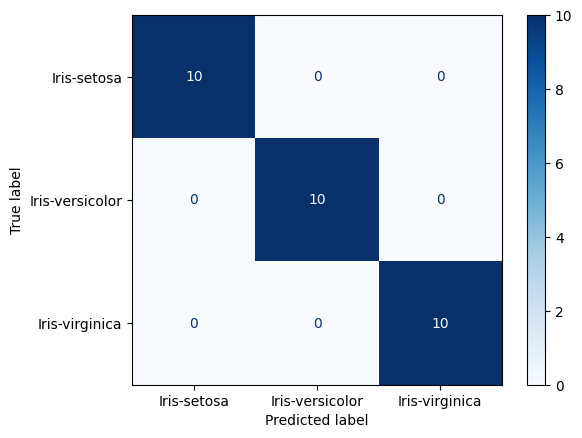

In [29]:
nomes_classes = iris.iloc[:, [4]].values
classes_unicas = np.unique(nomes_classes)
#print(classes_unicas)

cm = confusion_matrix(y_test, y_predicao)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes_unicas)
disp.plot(cmap='Blues')

No trecho abaixo, mostramos a forma de cálculo da acurácia. E também executamos o método accuracy_score que igualmente calcula a acurácia. Executando ainda o método classification_report que calcula as métricas conhecidas precision, recall e f-measure.

In [30]:
acerto = 0
for i in range(0, len(y_predicao)):
  if y_predicao[i]==y_test[i]: acerto = acerto + 1

print("Acuracia: ", acerto/len(y_predicao))
print(accuracy_score(y_test, y_predicao))
print(classification_report(y_test, y_predicao))

Acuracia:  1.0
1.0
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00        10
 Iris-virginica       1.00      1.00      1.00        10

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30



Abaixo, exibimos as classes e os pesos (modelo) encontrado no treinamento.

In [31]:
print("Classes: ", clf.classes_ )
print("Melhor loss: ", clf.best_loss_)
print(clf.coefs_)
print(clf.intercepts_)
print(clf.get_params)

Classes:  ['Iris-setosa' 'Iris-versicolor' 'Iris-virginica']
Melhor loss:  0.04829046105238052
[array([[ 6.16993992e-02, -4.53038353e-02,  4.04556809e-02,
         7.54703411e-02,  5.05289747e-01, -3.96524496e-01,
        -7.41380537e-01, -3.21795596e-01, -3.50887095e-01,
        -9.17558639e-05, -4.51065998e-01, -5.07707950e-01,
        -1.71943431e-02, -6.17267125e-02,  1.81738865e-01,
        -3.62410204e-01, -2.27586397e-01,  1.98790902e-01,
        -6.08317175e-01, -6.97851015e-01, -5.05406134e-01,
         3.67410524e-01, -3.99849142e-01, -6.53700349e-01,
        -5.25302029e-01, -3.42067572e-01, -1.51445644e-01,
        -6.05149949e-01, -1.71399002e-01,  5.60441365e-02,
         2.20008241e-01, -2.71963631e-01,  1.84391408e-01,
        -3.33897126e-01,  3.88017381e-01, -2.52779509e-01,
        -5.79735627e-01, -5.80458329e-02, -8.32848712e-01,
        -7.64917922e-01],
       [-4.45883935e-01, -7.78476854e-02, -5.54229493e-01,
        -3.81870585e-01,  3.18498584e-01, -3.8608311